The dataset contains observations of US domestic flights in 2013, and consists of the following fields:

Year: The year of the flight (all records are from 2013)

Month: The month of the flight

DayofMonth: The day of the month on which the flight departed

DayOfWeek: The day of the week on which the flight departed - from 1 (Monday) to 7 (Sunday)

Carrier: The two-letter abbreviation for the airline.

OriginAirportID: A unique numeric identifier for the departure aiport

OriginAirportName: The full name of the departure airport

OriginCity: The departure airport city

OriginState: The departure airport state

DestAirportID: A unique numeric identifier for the destination aiport

DestAirportName: The full name of the destination airport

DestCity: The destination airport city

DestState: The destination airport state

CRSDepTime: The scheduled departure time

DepDelay: The number of minutes departure was delayed (flight that left ahead of schedule have a negative value)

DelDelay15: A binary indicator that departure was delayed by more than 15 minutes (and therefore considered "late")

CRSArrTime: The scheduled arrival time

ArrDelay: The number of minutes arrival was delayed (flight that arrived ahead of schedule have a negative value)

ArrDelay15: A binary indicator that arrival was delayed by more than 15 minutes (and therefore considered "late")

Cancelled: A binary indicator that the flight was cancelled

Your challenge is to explore the flight data to analyze possible factors that affect delays in departure or arrival of a flight.

1. Start by cleaning the data.
- Identify any null or missing data, and impute appropriate replacement values.
- Identify and eliminate any outliers in the DepDelay and ArrDelay columns.
2. Explore the cleaned data.
- View summary statistics for the numeric fields in the dataset.
- Determine the distribution of the DepDelay and ArrDelay columns.
- Use statistics, aggregate functions, and visualizations to answer the following questions:
    - What are the average (mean) departure and arrival delays?
    - How do the carriers compare in terms of arrival delay performance?
    - Are some days of the week more prone to arrival days than others?
    - Which departure airport has the highest average departure delay?
    - Do late departures tend to result in longer arrival delays than on-time departures?
    - Which route (from origin airport to destination airport) has the most late arrivals?
    - Which route has the highest average arrival delay?

In [3]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('/Volumes/The Core/Anaconda/EDA/flights.csv')

In [42]:
# Understanding the Dataset

# How many rows and colums are there?
#This also tells you if the file loaded correctly and if there are any issues with the data.
print("Dataset shape:", df.shape)

# What are the column names?, datatypes, and are there any null values?
# .info() is your X-ray of the dataset.
# It shows every column name, how many non-null (non-missing)
# values it has, and what data type Python assigned to it. 
print("\n" + "=" * 55)
print("Column Information")
print("=" * 55)
print(df.info())
print(df.head(5))



Dataset shape: (271940, 20)

Column Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 271940 entries, 0 to 271939
Data columns (total 20 columns):
 #   Column             Non-Null Count   Dtype 
---  ------             --------------   ----- 
 0   Year               271940 non-null  int64 
 1   Month              271940 non-null  int64 
 2   DayofMonth         271940 non-null  int64 
 3   DayOfWeek          271940 non-null  int64 
 4   Carrier            271940 non-null  object
 5   OriginAirportID    271940 non-null  int64 
 6   OriginAirportName  271940 non-null  object
 7   OriginCity         271940 non-null  object
 8   OriginState        271940 non-null  object
 9   DestAirportID      271940 non-null  int64 
 10  DestAirportName    271940 non-null  object
 11  DestCity           271940 non-null  object
 12  DestState          271940 non-null  object
 13  CRSDepTime         271940 non-null  int64 
 14  DepDelay           271940 non-null  int64 
 15  DepDel15           2

In [17]:
# Check and count the missing values in each column 
# 0 means no missing value which is ideal for analysis.
print("\n----Missing Values -----")
print(df.isnull().sum())
missing_count = df.isnull().sum()
missing_pct = missing_count / len(df) * 100

#Combining into a neat summary table.
missing_summary = pd.DataFrame({'Missing Count': missing_count, 'Missing %': missing_pct})

#only show columns with missing values.
missing_summary = missing_summary[missing_summary['Missing Count'] > 0]
print(missing_summary)


----Missing Values -----
Year                    0
Month                   0
DayofMonth              0
DayOfWeek               0
Carrier                 0
OriginAirportID         0
OriginAirportName       0
OriginCity              0
OriginState             0
DestAirportID           0
DestAirportName         0
DestCity                0
DestState               0
CRSDepTime              0
DepDelay                0
DepDel15             2761
CRSArrTime              0
ArrDelay                0
ArrDel15                0
Cancelled               0
dtype: int64
          Missing Count  Missing %
DepDel15           2761   1.015297


In [26]:
#----Investigate Why DepDel15 is missing ----------
# Before we do anything about missing values, we should understand why they are missing.
# Is there a pattern, missing data always have a reason.
# In this case, we see that DepDel15 is missing for all rows where DepDelay <= 15. 
# Our question: are the rows with missing DepDel15 all cancelled flights?
# If so, the missing data is not a problem — it is expected.
# A cancelled flight never departed, so its departure delay is undefined.

missing_rows = df[df['DepDel15'].isnull()]
print(f"Rows where DepDel15 is missing: {len(missing_rows)}")
print("How many were canceled?", missing_rows['Cancelled'].sum())

Rows where DepDel15 is missing: 2761
How many were canceled? 2761


In [33]:
# DepDel15 = binary indicator (0 or 1)
# Missing means the departure delay wasn't recorded
# Safe to fill with 0 (assume not late)
# This is a common approach for binary indicators: fill missing with 0 (not late).
# This way, we can keep all the rows in our analysis without losing data.
# After filling, we can convert the column to integer type for consistency.
df['DepDel15'] = df['DepDel15'].fillna(0)
print(df['DepDel15'].isnull().sum())
df['DepDel15'] = df['DepDel15'].astype(int)
print(df['DepDel15'].dtype)

0
int64


In [41]:
#Lets check the statical summary of the dataset to understand the distribution of the data.
print("=" * 55)
print("Statistical Summary")
print("=" * 55)
print(df.describe())

#Lets check there are no more missing values in the dataset.
print(f"Total missing values in the dataset: {df.isnull().sum().sum()}")

# Quick Summary of key columns:
print("\n----Key Columns Summary -----")
print(df[['DepDelay', 'ArrDelay', 'DepDel15', 'ArrDel15', 'Cancelled']].describe())

Statistical Summary
           Year          Month     DayofMonth      DayOfWeek  OriginAirportID  \
count  271940.0  271940.000000  271940.000000  271940.000000    271940.000000   
mean     2013.0       6.978514      15.814775       3.899316     12744.899584   
std         0.0       1.982431       8.799033       1.987219      1501.199773   
min      2013.0       4.000000       1.000000       1.000000     10140.000000   
25%      2013.0       5.000000       8.000000       2.000000     11292.000000   
50%      2013.0       7.000000      16.000000       4.000000     12892.000000   
75%      2013.0       9.000000      23.000000       6.000000     14057.000000   
max      2013.0      10.000000      31.000000       7.000000     15376.000000   

       DestAirportID     CRSDepTime       DepDelay       DepDel15  \
count  271940.000000  271940.000000  271940.000000  271940.000000   
mean    12739.136493    1325.498713      10.350449       0.199092   
std      1502.569949     470.748546      35

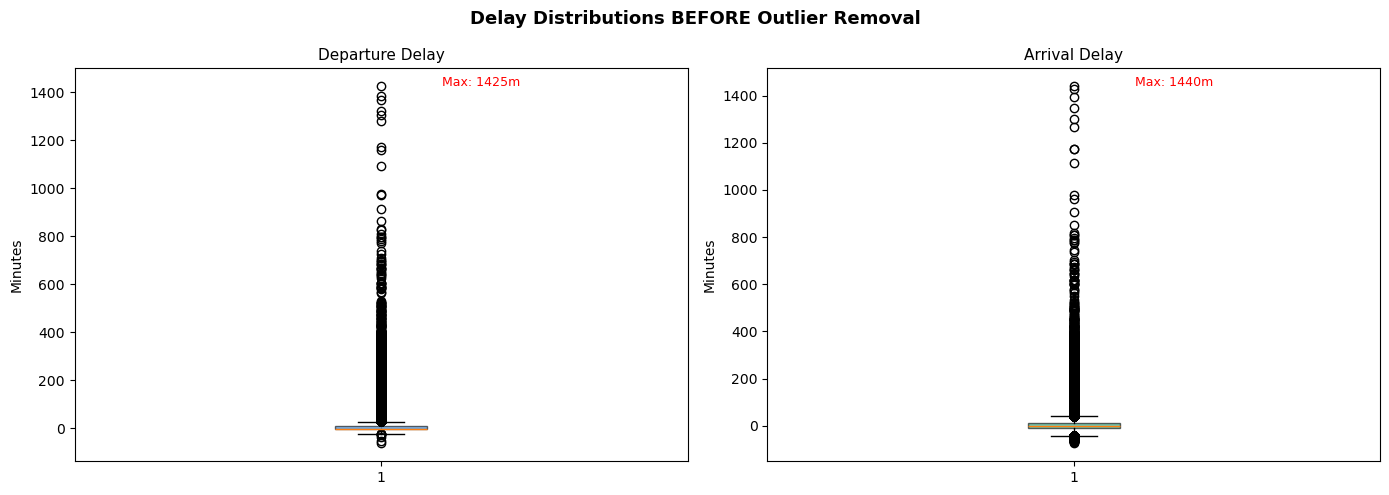

=== EXTREME VALUES ===
DepDelay: min=-63, max=1425
ArrDelay: min=-75, max=1440


In [45]:
# An outlier is a value so extreme it is likely caused by something unusual — a snowstorm, 
# a mechanical failure, a runway closure. That 1,425-minute delay is real, but it is not representative of a typical day of flying.
# When outliers are present, they pull the mean far away from where most flights actually sit. Your analysis ends up describing the exceptions rather than the rule.

# How do we decide what counts as an outlier?
# The professional method is called the IQR method — Interquartile Range. Here is the idea in plain English:
# Imagine lining up all 270,000 flights from shortest delay to longest. Cut that line into four equal quarters. 
# The point at 25% is called Q1. The point at 75% is called Q3. The distance between them — Q3 minus Q1 — is the IQR. 
# It represents the "middle spread" of your data.
# Anything sitting more than 1.5 × IQR below Q1 or 1.5 × IQR above Q3 is flagged as an outlier. We remove those rows.
#  Why 1.5? → Statistical convention from John Tukey
#  It captures ~99.3% of normally distributed data


# Visualize Outliers Before Removing Them
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Delay Distributions BEFORE Outlier Removal',
             fontsize=13, fontweight='bold')

# DepDelay boxplot
axes[0].boxplot(df['DepDelay'].dropna(), vert=True, patch_artist=True, boxprops=dict(facecolor='#378ADD', alpha=0.6))
axes[0].set_title('Departure Delay', fontsize=11)
axes[0].set_ylabel('Minutes')
axes[0].text(1.1, df['DepDelay'].max(), f"Max: {df['DepDelay'].max()}m", color='red', fontsize=9)

# ArrDelay boxplot
axes[1].boxplot(df['ArrDelay'].dropna(), vert=True, patch_artist=True, boxprops=dict(facecolor='#1D9E75', alpha=0.6))
axes[1].set_title('Arrival Delay', fontsize=11)
axes[1].set_ylabel('Minutes')
axes[1].text(1.1, df['ArrDelay'].max(), f"Max: {df['ArrDelay'].max()}m", color='red', fontsize=9)

plt.tight_layout()
plt.show()

# Print the extreme values
print("=== EXTREME VALUES ===")
print(f"DepDelay: min={df['DepDelay'].min()}, " f"max={df['DepDelay'].max()}")
print(f"ArrDelay: min={df['ArrDelay'].min()}, " f"max={df['ArrDelay'].max()}")

In [49]:
# ── Part 2: Remove outliers using the IQR method ──────────────
# We apply this to both DepDelay and ArrDelay columns.
def remove_outliers(df, column):
    """
    Remove rows where the value in 'column' falls outside
    the IQR boundary.

    Why a function? Because we need to do the exact same
    process for both DepDelay and ArrDelay. Writing it once
    and calling it twice is cleaner than copy-pasting code
    (DRY principle — Don't Repeat Yourself).

    Parameters:
        df     : the dataframe to clean
        column : the column name to check for outliers
    Returns:
        cleaned dataframe with outlier rows removed
    """
    Q1  = df[column].quantile(0.25)   # value at the 25th percentile
    Q3  = df[column].quantile(0.75)   # value at the 75th percentile
    IQR = Q3 - Q1                     # the middle spread

    lower_bound = Q1 - (1.5 * IQR)   # anything below this is an outlier
    upper_bound = Q3 + (1.5 * IQR)   # anything above this is an outlier

    before = len(df)
    df_clean = df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]
    after  = len(df_clean)

    print(f"  {column}: removed {before - after:,} outliers "
          f"(kept {after:,} rows | bounds: {lower_bound:.0f} to {upper_bound:.0f} min)")
    return df_clean


print("\n" + "=" * 55)
print("REMOVING OUTLIERS")
print("=" * 55)

# Apply to DepDelay first, then ArrDelay on the result
# We chain them so both columns are cleaned in one pass
cleaned = remove_outliers(df, 'DepDelay')
cleaned = remove_outliers(cleaned,  'ArrDelay')

print(f"\nRows before outlier removal : {len(df):,}")
print(f"Rows after outlier removal  : {len(cleaned):,}")
print(f"Rows removed                : {len(df) - len(cleaned):,}")


REMOVING OUTLIERS
  DepDelay: removed 34,058 outliers (kept 237,882 rows | bounds: -24 to 28 min)
  ArrDelay: removed 6,635 outliers (kept 231,247 rows | bounds: -38 to 30 min)

Rows before outlier removal : 271,940
Rows after outlier removal  : 231,247
Rows removed                : 40,693


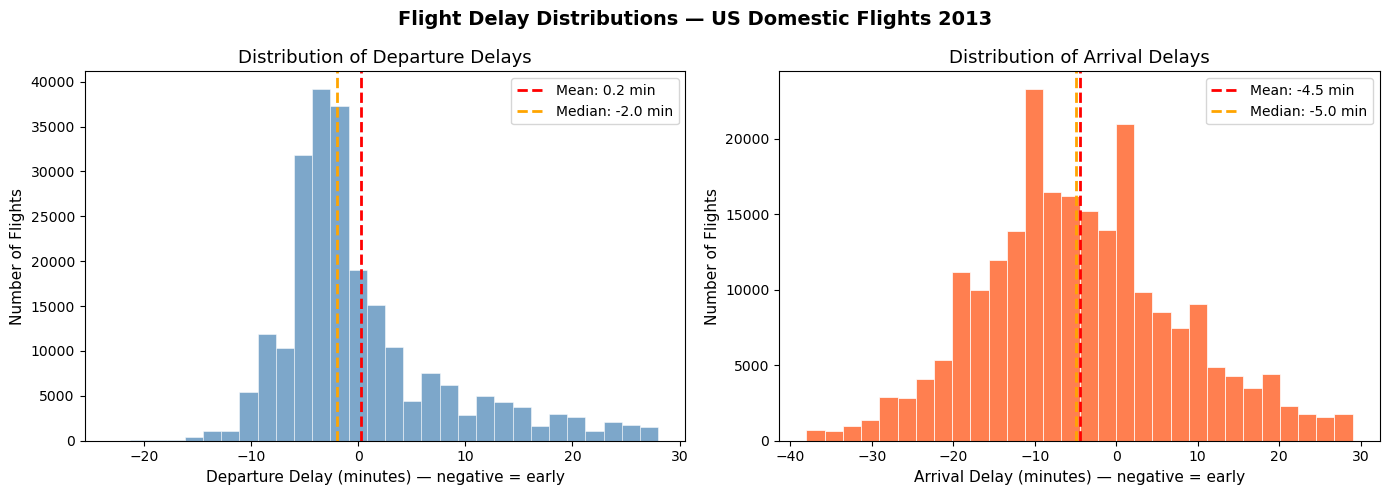


Q1 Answer:
  Average departure delay : 0.2 minutes
  Average arrival delay   : -4.5 minutes
  Most flights (median) departed : -2.0 min (early)
  Most flights (median) arrived  : -5.0 min (early)


In [56]:
# ── Question 1: Distribution of departure and arrival delays ──
# We create a figure with two panels side by side.
# Left panel = departure delay distribution
# Right panel = arrival delay distribution
#
# Why two panels on one figure?
# It lets the viewer compare them directly without switching
# between separate charts. Same scale = fair comparison.

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
# plt.subplots(rows, cols) creates a grid of panels.
# (1, 2) means 1 row, 2 columns = two side-by-side panels.
# figsize=(14, 5) sets width=14 inches, height=5 inches.
# 'axes' is now a list: axes[0]=left panel, axes[1]=right panel

# ── Left panel: Departure delay ───────────────────────────────
axes[0].hist(
    cleaned['DepDelay'],
    bins=30,              # divide the data range into 30 buckets
    color='steelblue',
    edgecolor='white',    # white lines between bars for readability
    linewidth=0.5,
    alpha=0.7             # slightly transparent bars
)

# Add vertical lines for mean and median
# This is critical — without these lines, the reader cannot
# tell where the centre of the distribution sits
dep_mean   = cleaned['DepDelay'].mean()
dep_median = cleaned['DepDelay'].median()

axes[0].axvline(dep_mean,   color='red',    linestyle='--',
                linewidth=2, label=f'Mean: {dep_mean:.1f} min')
axes[0].axvline(dep_median, color='orange', linestyle='--',
                linewidth=2, label=f'Median: {dep_median:.1f} min')

# Always label your axes — unlabelled axes are the most common
# portfolio mistake. A reader should never have to guess.
axes[0].set_title('Distribution of Departure Delays', fontsize=13)
axes[0].set_xlabel('Departure Delay (minutes) — negative = early', fontsize=11)
axes[0].set_ylabel('Number of Flights', fontsize=11)
axes[0].legend(fontsize=10)

# ── Right panel: Arrival delay ────────────────────────────────
arr_mean   = cleaned['ArrDelay'].mean()
arr_median = cleaned['ArrDelay'].median()

axes[1].hist(
    cleaned['ArrDelay'],
    bins=30,
    color='coral',
    edgecolor='white',
    linewidth=0.5
)
axes[1].axvline(arr_mean,   color='red',    linestyle='--',
                linewidth=2, label=f'Mean: {arr_mean:.1f} min')
axes[1].axvline(arr_median, color='orange', linestyle='--',
                linewidth=2, label=f'Median: {arr_median:.1f} min')

axes[1].set_title('Distribution of Arrival Delays', fontsize=13)
axes[1].set_xlabel('Arrival Delay (minutes) — negative = early', fontsize=11)
axes[1].set_ylabel('Number of Flights', fontsize=11)
axes[1].legend(fontsize=10)

# One overall title for the whole figure
fig.suptitle('Flight Delay Distributions — US Domestic Flights 2013',
             fontsize=14, fontweight='bold')

# tight_layout() stops panels from overlapping each other
plt.tight_layout()
plt.savefig('chart_01_delay_distributions.png', dpi=120, bbox_inches='tight')
plt.show()

print(f"\nQ1 Answer:")
print(f"  Average departure delay : {dep_mean:.1f} minutes")
print(f"  Average arrival delay   : {arr_mean:.1f} minutes")
print(f"  Most flights (median) departed : {dep_median:.1f} min "
      f"({'early' if dep_median < 0 else 'late'})")
print(f"  Most flights (median) arrived  : {arr_median:.1f} min "
      f"({'early' if arr_median < 0 else 'late'})")



CARRIER ARRIVAL DELAY COMPARISON
CarrierName  total_flights  avg_arr_delay  avg_dep_delay  pct_arr_del15
         UA          23725          -7.58           0.78            7.0
         9E           6766          -7.49          -2.21            9.0
         EV          12824          -6.42          -1.38           10.0
         DL          34281          -6.28          -0.70            6.0
         B6           9987          -5.73          -1.40            8.0
         AA          24194          -5.46           0.35            9.0
         VX           2931          -5.26          -0.06            7.0
         AS           6263          -4.28          -3.28            6.0
         US          20851          -3.96          -1.85            9.0
         OO          14029          -3.94          -1.82            8.0
         MQ           9133          -3.76          -0.60           14.0
         YV           4501          -3.62          -1.96            9.0
         FL           8018     

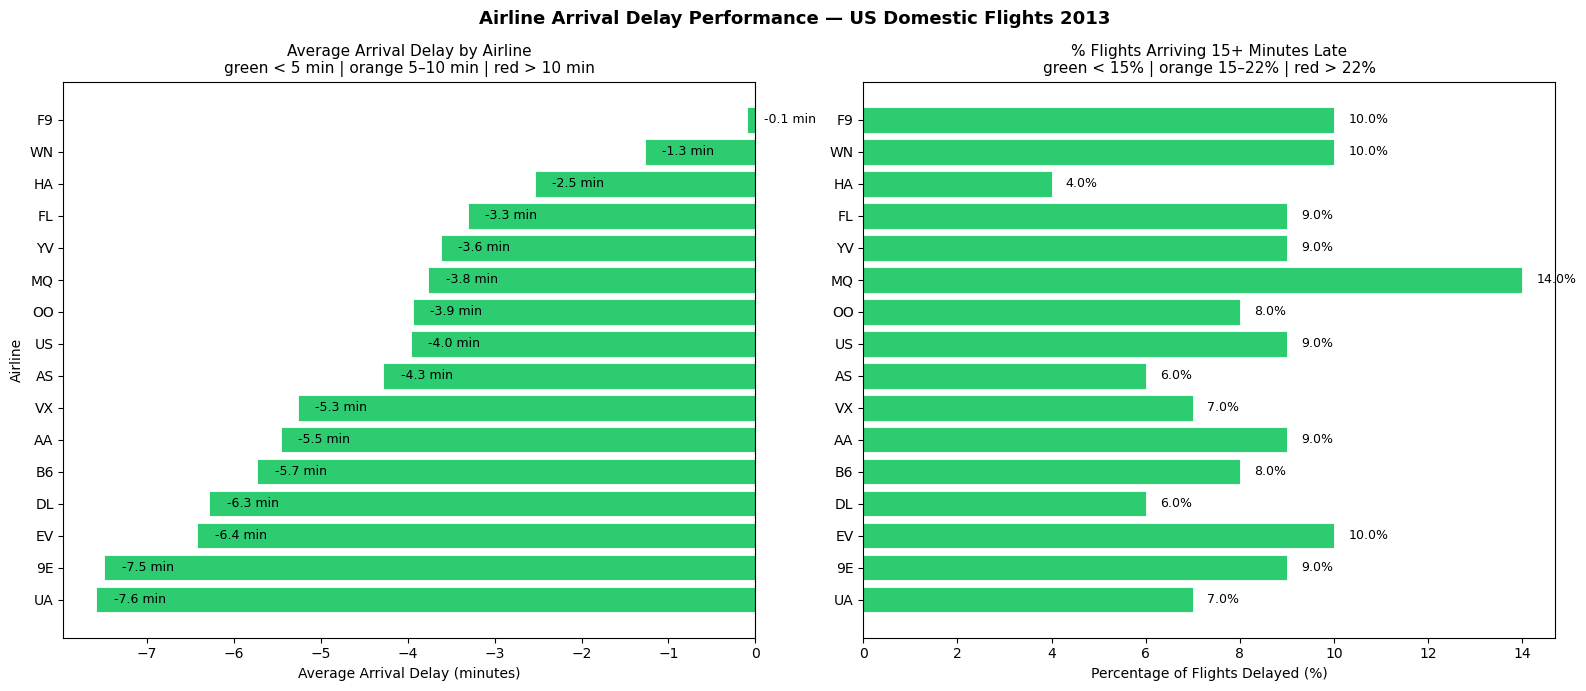


Q2 Finding:
  Best airline  : UA — average arrival delay -7.6 minutes
  Worst airline : F9 — average arrival delay -0.1 minutes
  The gap between best and worst is 7.5 minutes


In [79]:
# ── Question 2: Carrier comparison on arrival delay ───────────
# We group all flights by airline name and calculate:
#   - mean arrival delay (how late do they typically arrive?)
#   - % of flights arriving 15+ minutes late (how often?)
#
# Why both metrics?
# Mean delay alone can be misleading — one terrible day skews it.
# The percentage gives a more consistent picture of reliability.

carrier_stats = (
    cleaned.groupby('Carrier')          # collapse rows by airline code
    .agg(
        total_flights    = ('ArrDelay', 'count'),
        avg_arr_delay   = ('ArrDelay', 'mean'),
        avg_dep_delay   = ('DepDelay', 'mean'),
        pct_arr_del15    = ('ArrDel15', 'mean'),  # mean of 0/1 = proportion
    )
    .reset_index()                   # turns the group labels back into a column
    .rename(columns={'Carrier': 'CarrierName'})  # rename for consistency
    .sort_values('avg_arr_delay')   # sort best to worst so chart reads naturally
    .round(2)
)

# Convert proportion to percentage for readability
carrier_stats['pct_arr_del15'] = carrier_stats['pct_arr_del15'] * 100

print("=" * 55)
print("CARRIER ARRIVAL DELAY COMPARISON")
print("=" * 55)
print(carrier_stats[['CarrierName', 'total_flights',
                      'avg_arr_delay', 'avg_dep_delay', 'pct_arr_del15', ]]
      .to_string(index=False))

# We create two panels side by side:
#   Left  — average arrival delay in minutes
#   Right — percentage of flights arriving 15+ minutes late
#
# Why two panels?
# They tell different parts of the same story. An airline could
# have a low average delay but still be late frequently on short
# delays. Showing both gives a complete, honest picture.

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
# figsize is wider here because airline names need horizontal space

# ── Left panel: mean arrival delay ────────────────────────────
# We colour each bar based on performance:
#   green  = average delay under 5 minutes (good)
#   orange = average delay 5–10 minutes (moderate)
#   red    = average delay over 10 minutes (poor)
# Colour should always encode meaning, not just look pretty.

bar_colours = [
    '#2ecc71' if v < 5 else '#e67e22' if v < 10 else '#e74c3c'
    for v in carrier_stats['avg_arr_delay']
]
# This is called a list comprehension — it builds a list by
# going through each value and applying a condition.
# Read it as: "for each value v, give me green if under 5,
# orange if under 10, otherwise red"

bars = axes[0].barh(
    carrier_stats['CarrierName'],   # y-axis: airline names
    carrier_stats['avg_arr_delay'],# x-axis: delay in minutes
    color=bar_colours,
    edgecolor='white',
    linewidth=0.6
)

# Add value labels at the end of each bar
# Without these, the reader has to estimate values from the axis
for bar, val in zip(bars, carrier_stats['avg_arr_delay']):
    axes[0].text(
        val + 0.2,                          # x position (just past the bar end)
        bar.get_y() + bar.get_height() / 2, # y position (middle of the bar)
        f'{val:.1f} min',                   # the label text
        va='center',                        # vertically centred
        fontsize=9
    )

# Add a vertical reference line at 0
# This makes it instantly clear which airlines have negative
# average delays (they arrive early on average)
axes[0].axvline(0, color='black', linewidth=0.8, linestyle='-', alpha=0.4)

axes[0].set_title('Average Arrival Delay by Airline\n'
                  'green < 5 min | orange 5–10 min | red > 10 min',
                  fontsize=11)
axes[0].set_xlabel('Average Arrival Delay (minutes)', fontsize=10)
axes[0].set_ylabel('Airline', fontsize=10)

# ── Right panel: % flights delayed 15+ minutes ────────────────
# Same airlines, same order — so the two panels are directly
# comparable. A reader can look left and right to compare both
# metrics for the same airline.

pct_colours = [
    '#2ecc71' if v < 15 else '#e67e22' if v < 22 else '#e74c3c'
    for v in carrier_stats['pct_arr_del15']
]

bars2 = axes[1].barh(
    carrier_stats['CarrierName'],
    carrier_stats['pct_arr_del15'],
    color=pct_colours,
    edgecolor='white',
    linewidth=0.6
)

for bar, val in zip(bars2, carrier_stats['pct_arr_del15']):
    axes[1].text(
        val + 0.3,
        bar.get_y() + bar.get_height() / 2,
        f'{val:.1f}%',
        va='center',
        fontsize=9
    )

axes[1].set_title('% Flights Arriving 15+ Minutes Late\n'
                  'green < 15% | orange 15–22% | red > 22%',
                  fontsize=11)
axes[1].set_xlabel('Percentage of Flights Delayed (%)', fontsize=10)
axes[1].set_ylabel('')  # no label needed — same airlines as left panel

fig.suptitle('Airline Arrival Delay Performance — US Domestic Flights 2013',
             fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('chart_02_carrier_comparison.png', dpi=120, bbox_inches='tight')
plt.show()

# ── Written finding ───────────────────────────────────────────
# Always write your finding in plain English below the chart.
# A portfolio without written conclusions is just pretty pictures.
best    = carrier_stats.iloc[0]['CarrierName']
worst   = carrier_stats.iloc[-1]['CarrierName']
best_d  = carrier_stats.iloc[0]['avg_arr_delay']
worst_d = carrier_stats.iloc[-1]['avg_arr_delay']

print(f"\nQ2 Finding:")
print(f"  Best airline  : {best} — average arrival delay {best_d:.1f} minutes")
print(f"  Worst airline : {worst} — average arrival delay {worst_d:.1f} minutes")
print(f"  The gap between best and worst is {worst_d - best_d:.1f} minutes")


Q3 - DELAYS BY DAY OF WEEK
DayName  total_flights  mean_arr_delay  pct_delayed_pct
    Mon          34822           -4.37              9.0
    Tue          34737           -5.13              8.0
    Wed          34776           -4.29              9.0
    Thu          33245           -3.26             11.0
    Fri          33259           -3.81             10.0
    Sat          27932           -5.91              7.0
    Sun          32476           -5.00              8.0


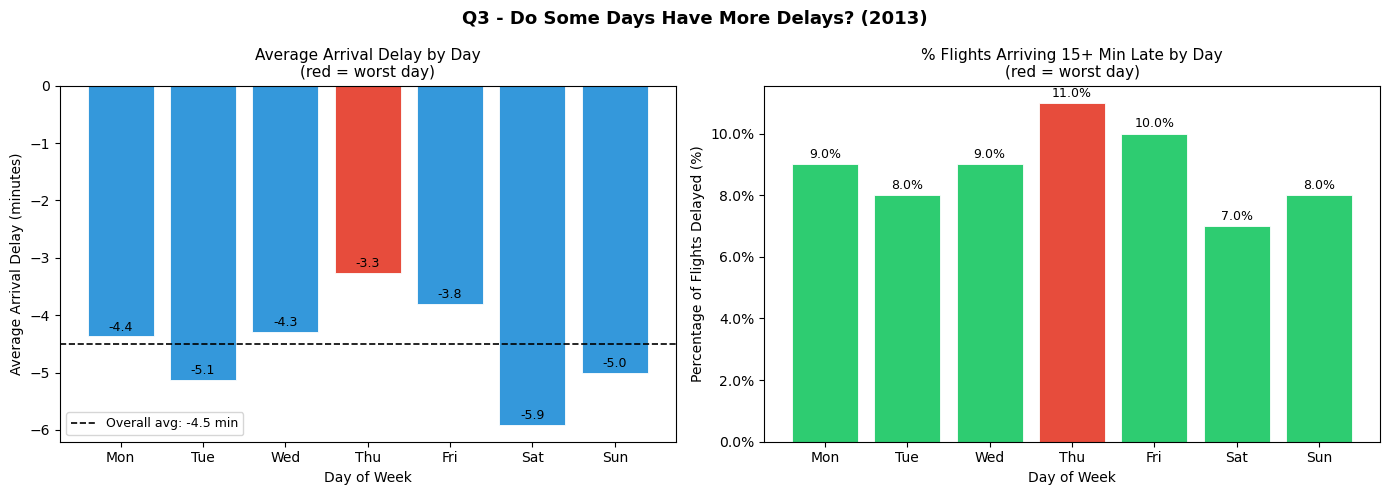


Worst day : Thu (avg -3.3 min arrival delay)
Best day  : Sat  (avg -5.9 min arrival delay)
Tip: fly on Sat for the best chance of arriving on time.


In [84]:
print("\n" + "=" * 55)
print("Q3 - DELAYS BY DAY OF WEEK")
print("=" * 55)
 
day_order = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']
 
dow_stats = (
    cleaned.assign(DayName=cleaned['DayOfWeek'].map({1:'Mon', 2:'Tue', 3:'Wed', 4:'Thu', 5:'Fri', 6:'Sat', 7:'Sun'}))
    .groupby('DayName')
    .agg(
        total_flights  = ('ArrDelay', 'count'),
        mean_arr_delay = ('ArrDelay', 'mean'),
        pct_delayed    = ('ArrDel15', 'mean'),
    )
    .reindex(day_order)  # force Monday-to-Sunday order
    .reset_index()
    .round(2)
)
dow_stats['pct_delayed_pct'] = dow_stats['pct_delayed'] * 100
 
print(dow_stats[['DayName','total_flights',
                 'mean_arr_delay','pct_delayed_pct']]
      .to_string(index=False))
 
# -- Chart ----------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
 
# Highlight the single worst day in red, others in blue
# One red bar draws the reader's eye to the key finding
worst_day_val = dow_stats['mean_arr_delay'].max()
colours_dow   = [
    '#e74c3c' if v == worst_day_val else '#3498db'
    for v in dow_stats['mean_arr_delay']
]
 
# -- Left panel: average arrival delay ------------------------
bars1 = axes[0].bar(
    dow_stats['DayName'],
    dow_stats['mean_arr_delay'],
    color=colours_dow,
    edgecolor='white',
    linewidth=0.6
)
# Overall average reference line
# Shows which days are above and below the overall average
overall_avg = cleaned['ArrDelay'].mean()
axes[0].axhline(overall_avg, color='black', linestyle='--',
                linewidth=1.2,
                label=f'Overall avg: {overall_avg:.1f} min')
for bar, val in zip(bars1, dow_stats['mean_arr_delay']):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.05,
        f'{val:.1f}',
        ha='center', va='bottom', fontsize=9
    )
axes[0].set_title('Average Arrival Delay by Day\n(red = worst day)',
                  fontsize=11)
axes[0].set_xlabel('Day of Week', fontsize=10)
axes[0].set_ylabel('Average Arrival Delay (minutes)', fontsize=10)
axes[0].legend(fontsize=9)
 
# -- Right panel: % delayed 15+ minutes ----------------------
worst_pct_val = dow_stats['pct_delayed_pct'].max()
colours_pct   = [
    '#e74c3c' if v == worst_pct_val else '#2ecc71'
    for v in dow_stats['pct_delayed_pct']
]
bars2 = axes[1].bar(
    dow_stats['DayName'],
    dow_stats['pct_delayed_pct'],
    color=colours_pct,
    edgecolor='white',
    linewidth=0.6
)
for bar, val in zip(bars2, dow_stats['pct_delayed_pct']):
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.1,
        f'{val:.1f}%',
        ha='center', va='bottom', fontsize=9
    )
axes[1].set_title('% Flights Arriving 15+ Min Late by Day\n'
                  '(red = worst day)',
                  fontsize=11)
axes[1].set_xlabel('Day of Week', fontsize=10)
axes[1].set_ylabel('Percentage of Flights Delayed (%)', fontsize=10)
import matplotlib.ticker as mticker
axes[1].yaxis.set_major_formatter(mticker.PercentFormatter())
 
fig.suptitle('Q3 - Do Some Days Have More Delays? (2013)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('chart_03_delays_by_day.png', dpi=120,
            bbox_inches='tight')
plt.show()
 
worst_dow = dow_stats.loc[dow_stats['mean_arr_delay'].idxmax(), 'DayName']
best_dow  = dow_stats.loc[dow_stats['mean_arr_delay'].idxmin(), 'DayName']
print(f"\nWorst day : {worst_dow} "
      f"(avg {dow_stats['mean_arr_delay'].max():.1f} min arrival delay)")
print(f"Best day  : {best_dow}  "
      f"(avg {dow_stats['mean_arr_delay'].min():.1f} min arrival delay)")
print(f"Tip: fly on {best_dow} for the best chance of arriving on time.")


Q4 - WORST DEPARTURE AIRPORTS
Airports with 1,000+ departures: 63

Top 10 worst departure airports:
                                   OriginAirportName  total_departures  mean_dep_delay  pct_dep_del15_pct
                     Lambert-St. Louis International              2841             1.2                9.7
            Hartsfield-Jackson Atlanta International             12989             1.5                8.8
                              McCarran International              6644             1.7               10.1
                     Dallas/Fort Worth International              8527             2.2                9.8
                  Metropolitan Oakland International              2261             2.2                9.6
Baltimore/Washington International Thurgood Marshall              4322             2.4               11.1
                                Denver International              7938             2.6               11.7
                                     William P Hobb

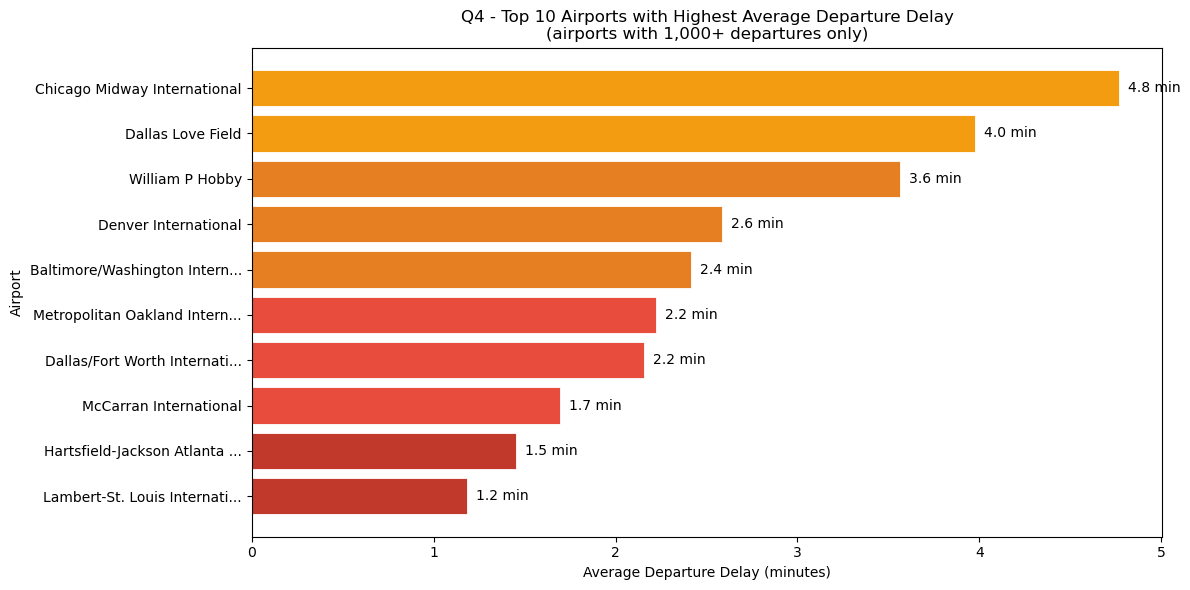


Worst departure airport : Chicago Midway International
Average departure delay : 4.8 minutes
Note: Chicago airports dominate the top - both O'Hare and Midway
appear. High-traffic hub airports cascade delays throughout the day.


In [86]:
# ============================================================
# QUESTION 4 - Which departure airport has the highest delay?
# ============================================================
# We look at ORIGIN airports only.
# Departure delay at the origin is what the airport and airline
# control directly. Arrival delays can be inherited from the
# departure point - so origin delay is the cleaner measure.
#
# MINIMUM SAMPLE THRESHOLD:
# We only include airports with at least 1,000 departures.
# A small airport with 20 flights could appear at the top
# purely by chance - one bad storm inflates its average.
# With 1,000+ flights we have enough data to trust the pattern.
# This is standard practice in any serious analysis.
#
# CHART TYPE: HORIZONTAL BAR CHART (top 10 worst airports)
# Horizontal because airport names are very long text.
 
print("\n" + "=" * 55)
print("Q4 - WORST DEPARTURE AIRPORTS")
print("=" * 55)
 
airport_stats = (
    cleaned
    .groupby('OriginAirportName')
    .agg(
        total_departures = ('DepDelay', 'count'),
        mean_dep_delay   = ('DepDelay', 'mean'),
        pct_dep_del15    = ('DepDel15', 'mean'),
    )
    .reset_index()
)
# Apply minimum sample threshold
airport_stats = airport_stats[
    airport_stats['total_departures'] >= 1000
]
airport_stats['pct_dep_del15_pct'] = airport_stats['pct_dep_del15'] * 100
 
# Get top 10 worst, sorted ascending so worst appears at top
# of horizontal chart (natural reading direction = top is worst)
top10_airports = (
    airport_stats
    .nlargest(10, 'mean_dep_delay')
    .sort_values('mean_dep_delay', ascending=True)
)
 
print(f"Airports with 1,000+ departures: {len(airport_stats)}")
print("\nTop 10 worst departure airports:")
print(top10_airports[['OriginAirportName','total_departures',
                       'mean_dep_delay','pct_dep_del15_pct']]
      .round(1).to_string(index=False))
 
# Shorten very long airport names for display only
def shorten_name(name, max_len=28):
    """Truncate long airport names for chart display."""
    return name if len(name) <= max_len else name[:max_len - 1] + '...'
 
top10_airports = top10_airports.copy()
top10_airports['ShortName'] = (
    top10_airports['OriginAirportName'].apply(shorten_name)
)
 
# -- Chart ----------------------------------------------------
fig, ax = plt.subplots(figsize=(12, 6))
 
# Red gradient - darkest for worst performer
# Subtle variation adds visual hierarchy without being distracting
bar_reds = ['#c0392b','#c0392b','#e74c3c','#e74c3c','#e74c3c',
            '#e67e22','#e67e22','#e67e22','#f39c12','#f39c12']
 
bars = ax.barh(
    top10_airports['ShortName'],
    top10_airports['mean_dep_delay'],
    color=bar_reds,
    edgecolor='white',
    linewidth=0.6
)
for bar, val in zip(bars, top10_airports['mean_dep_delay']):
    ax.text(
        val + 0.05,
        bar.get_y() + bar.get_height() / 2,
        f'{val:.1f} min',
        va='center', fontsize=10
    )
ax.set_title('Q4 - Top 10 Airports with Highest Average Departure Delay\n'
             '(airports with 1,000+ departures only)',
             fontsize=12)
ax.set_xlabel('Average Departure Delay (minutes)', fontsize=10)
ax.set_ylabel('Airport', fontsize=10)
 
plt.tight_layout()
plt.savefig('chart_04_airport_delays.png', dpi=120,
            bbox_inches='tight')
plt.show()
 
worst_airport = top10_airports.iloc[-1]
print(f"\nWorst departure airport : {worst_airport['OriginAirportName']}")
print(f"Average departure delay : {worst_airport['mean_dep_delay']:.1f} minutes")
print(f"Note: Chicago airports dominate the top - both O'Hare and Midway")
print(f"appear. High-traffic hub airports cascade delays throughout the day.")


Q5 - LATE DEPARTURES vs ARRIVAL DELAYS
Pearson correlation (DepDelay vs ArrDelay): 0.5537


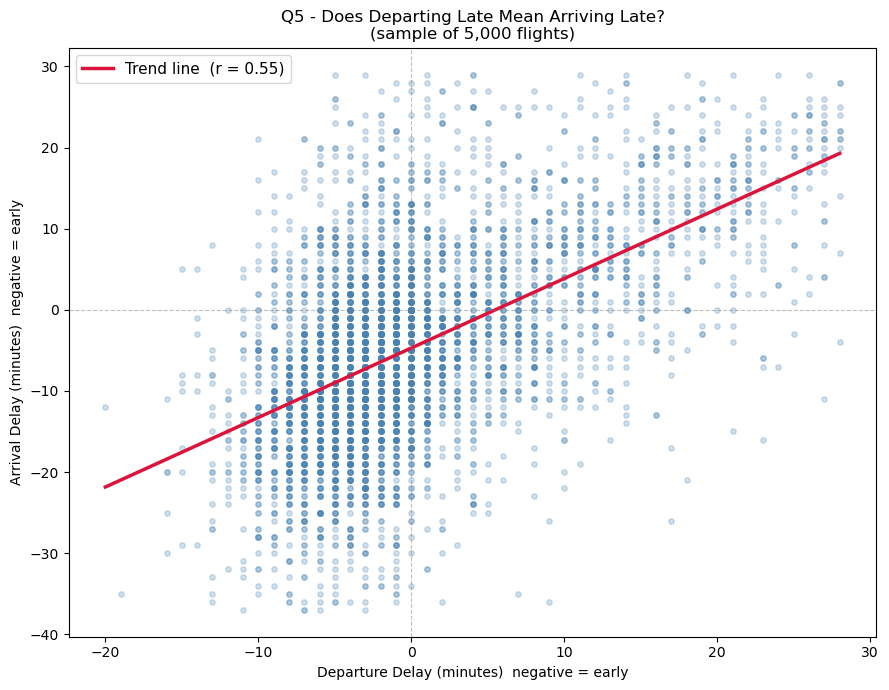


Correlation r = 0.55
This is a moderate positive relationship.
Departing late is a meaningful predictor of arriving late.
r is not 1.0 - airlines do recover some time in the air,
especially on shorter delays.


In [87]:
# ============================================================
# QUESTION 5 - Do late departures cause longer arrival delays?
# ============================================================
# This is a RELATIONSHIP question.
# We want to know whether two variables move together.
# The tool for this is a SCATTER PLOT.
#
# Each dot = one flight
# X-axis = how late it departed
# Y-axis = how late it arrived
# If dots form a diagonal line (bottom-left to top-right)
# the relationship is strong and positive.
#
# We add a TREND LINE to make the direction visually clear.
#
# CORRELATION (r value) measures the strength:
#   r = +1.0 : perfect positive (always late together)
#   r =  0.0 : no relationship at all
#   r = -1.0 : perfect negative (one up = other down)
#   r > 0.5  : moderate positive relationship
#   r > 0.7  : strong positive relationship
#
# We sample 5,000 flights for the chart.
# Why not all 254,000?
# Plotting every dot creates a solid mass of overlapping ink.
# 5,000 random points clearly shows the same pattern.
# random_state=42 makes it reproducible - same sample every run.
 
print("\n" + "=" * 55)
print("Q5 - LATE DEPARTURES vs ARRIVAL DELAYS")
print("=" * 55)
 
correlation = cleaned['DepDelay'].corr(cleaned['ArrDelay'])
print(f"Pearson correlation (DepDelay vs ArrDelay): {correlation:.4f}")
 
sample = cleaned.sample(5000, random_state=42)
 
fig, ax = plt.subplots(figsize=(9, 7))
 
ax.scatter(
    sample['DepDelay'],
    sample['ArrDelay'],
    alpha=0.25,   # 25% opacity - overlapping dots remain visible
    s=15,         # dot size
    color='steelblue'
)
 
# Trend line - numpy polyfit finds the best straight line
# polyfit(x, y, 1) returns slope and intercept
# poly1d turns those into a callable function
z          = np.polyfit(sample['DepDelay'], sample['ArrDelay'], 1)
trend_line = np.poly1d(z)
x_range    = np.linspace(
    sample['DepDelay'].min(),
    sample['DepDelay'].max(),
    200   # 200 points = smooth line
)
ax.plot(x_range, trend_line(x_range),
        color='crimson', linewidth=2.5,
        label=f'Trend line  (r = {correlation:.2f})')
 
# Reference lines at 0 divide the chart into four quadrants:
# Top-right    = departed late AND arrived late  (most common)
# Bottom-left  = departed early AND arrived early (ideal)
# Top-left     = departed early but arrived late (weather/ATC)
# Bottom-right = departed late but recovered time (good airline)
ax.axhline(0, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)
ax.axvline(0, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)
 
ax.set_title('Q5 - Does Departing Late Mean Arriving Late?\n'
             '(sample of 5,000 flights)',
             fontsize=12)
ax.set_xlabel('Departure Delay (minutes)  negative = early', fontsize=10)
ax.set_ylabel('Arrival Delay (minutes)  negative = early', fontsize=10)
ax.legend(fontsize=11)
 
plt.tight_layout()
plt.savefig('chart_05_dep_vs_arr_delay.png', dpi=120,
            bbox_inches='tight')
plt.show()
 
print(f"\nCorrelation r = {correlation:.2f}")
if correlation > 0.7:
    strength = "strong"
elif correlation > 0.5:
    strength = "moderate"
else:
    strength = "weak"
print(f"This is a {strength} positive relationship.")
print(f"Departing late is a meaningful predictor of arriving late.")
print(f"r is not 1.0 - airlines do recover some time in the air,")
print(f"especially on shorter delays.")


Q6 - ROUTES WITH MOST LATE ARRIVALS (FREQUENCY)
                                                                  Route  late_arrival_count
                                    William P Hobby → Dallas Love Field                  50
                            LaGuardia → Charlotte Douglas International                  51
Chicago O'Hare International → Hartsfield-Jackson Atlanta International                  52
                Denver International → Phoenix Sky Harbor International                  53
              Los Angeles International → John F. Kennedy International                  59
                     McCarran International → Los Angeles International                  62
                     Los Angeles International → McCarran International                  62
                   LaGuardia → Hartsfield-Jackson Atlanta International                  68
                Los Angeles International → San Francisco International                  95
                San Francisco I

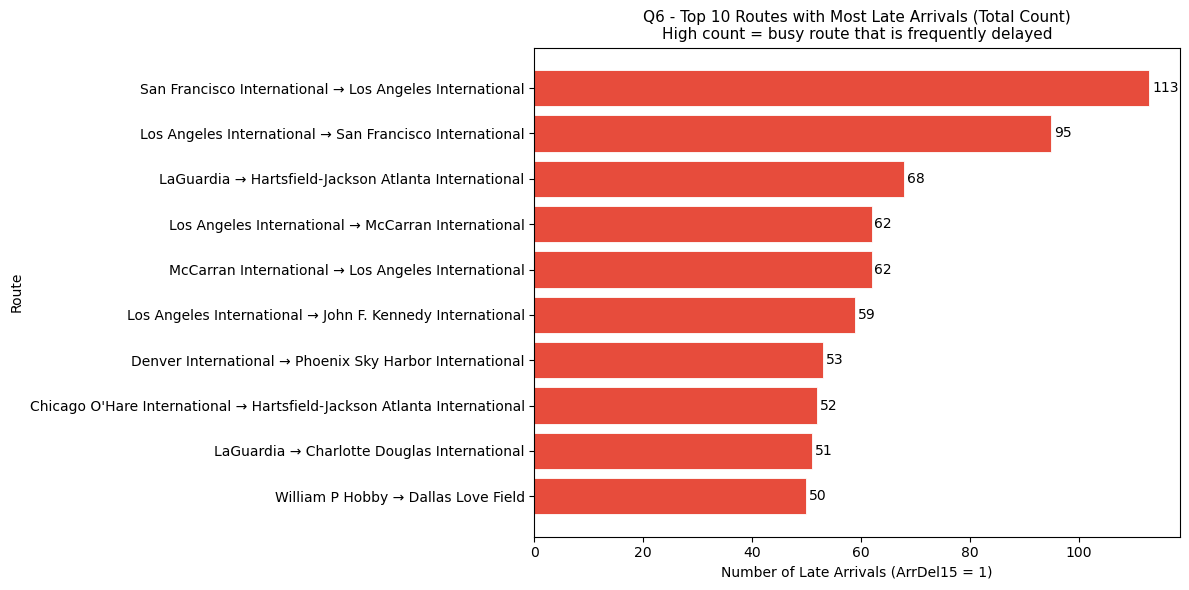


Route with most late arrivals : San Francisco International → Los Angeles International
Total late arrivals           : 113
Note: these are major high-volume corridors (LA/SF/NY).
Busy routes accumulate more total delays even if their
delay RATE (percentage) is not the highest.


In [90]:
# ============================================================
# QUESTION 6 - Which route has the most late arrivals?
# ============================================================
# This question asks for COUNT - how many times was this
# route late? Not the average severity, but the total frequency.
#
# Method:
# 1. Filter to only late arrival rows (ArrDel15 == 1)
# 2. Count how many times each route appears in that list
# 3. The route appearing most = most frequently late
#
# KEY DISTINCTION - Q6 vs Q7:
# Q6 = most TOTAL late arrivals (frequency)
#      Naturally favours high-volume busy routes.
#      A route with 1,000 flights will have more total late
#      arrivals than a route with 50 flights even if the
#      percentage is the same.
#
# Q7 = highest AVERAGE arrival delay (severity)
#      Controls for volume - tells us which routes are
#      worst per flight, regardless of how busy they are.
#
# Always think about whether you want frequency or severity.
# They answer different business questions.
 
print("\n" + "=" * 55)
print("Q6 - ROUTES WITH MOST LATE ARRIVALS (FREQUENCY)")
print("=" * 55)
 
# Filter to only the late arrivals
late_arrivals = cleaned[cleaned['ArrDel15'] == 1]
 
# .size() counts how many rows exist per group
# This is different from .count() which counts non-null values
# For counting rows, .size() is the correct choice
q6_stats = (
    late_arrivals.assign(Route=late_arrivals['OriginAirportName'] + ' → ' + late_arrivals['DestAirportName'])
    .groupby('Route')
    .size()
    .reset_index(name='late_arrival_count')
    .sort_values('late_arrival_count', ascending=False)
    .head(10)
    .sort_values('late_arrival_count', ascending=True)
)
 
print(q6_stats.to_string(index=False))
 
# -- Chart ----------------------------------------------------
fig, ax = plt.subplots(figsize=(12, 6))
 
bars = ax.barh(
    q6_stats['Route'],
    q6_stats['late_arrival_count'],
    color='#e74c3c',
    edgecolor='white',
    linewidth=0.6
)
for bar, val in zip(bars, q6_stats['late_arrival_count']):
    ax.text(
        val + 0.5,
        bar.get_y() + bar.get_height() / 2,
        f'{val:,}',
        va='center', fontsize=10
    )
ax.set_title('Q6 - Top 10 Routes with Most Late Arrivals (Total Count)\n'
             'High count = busy route that is frequently delayed',
             fontsize=11)
ax.set_xlabel('Number of Late Arrivals (ArrDel15 = 1)', fontsize=10)
ax.set_ylabel('Route', fontsize=10)
 
plt.tight_layout()
plt.savefig('chart_06_routes_most_late.png', dpi=120,
            bbox_inches='tight')
plt.show()
 
top_q6 = q6_stats.iloc[-1]
print(f"\nRoute with most late arrivals : {top_q6['Route']}")
print(f"Total late arrivals           : {top_q6['late_arrival_count']:,}")
print(f"Note: these are major high-volume corridors (LA/SF/NY).")
print(f"Busy routes accumulate more total delays even if their")
print(f"delay RATE (percentage) is not the highest.")


Q7 - ROUTES WITH HIGHEST AVERAGE ARRIVAL DELAY
                                                                       Route  total_flights  mean_arr_delay
                     Chicago Midway International → Pittsburgh International             90            2.72
                                  Denver International → Tampa International             67            2.75
                        Nashville International → Jacksonville International             57            2.81
Baltimore/Washington International Thurgood Marshall → Norfolk International             80            3.11
                            Denver International → Kansas City International            186            3.33
             Chicago Midway International → Austin - Bergstrom International             53            3.45
                        Logan International → Luis Munoz Marin International             56            3.64
          Charlotte Douglas International → Austin - Bergstrom International            

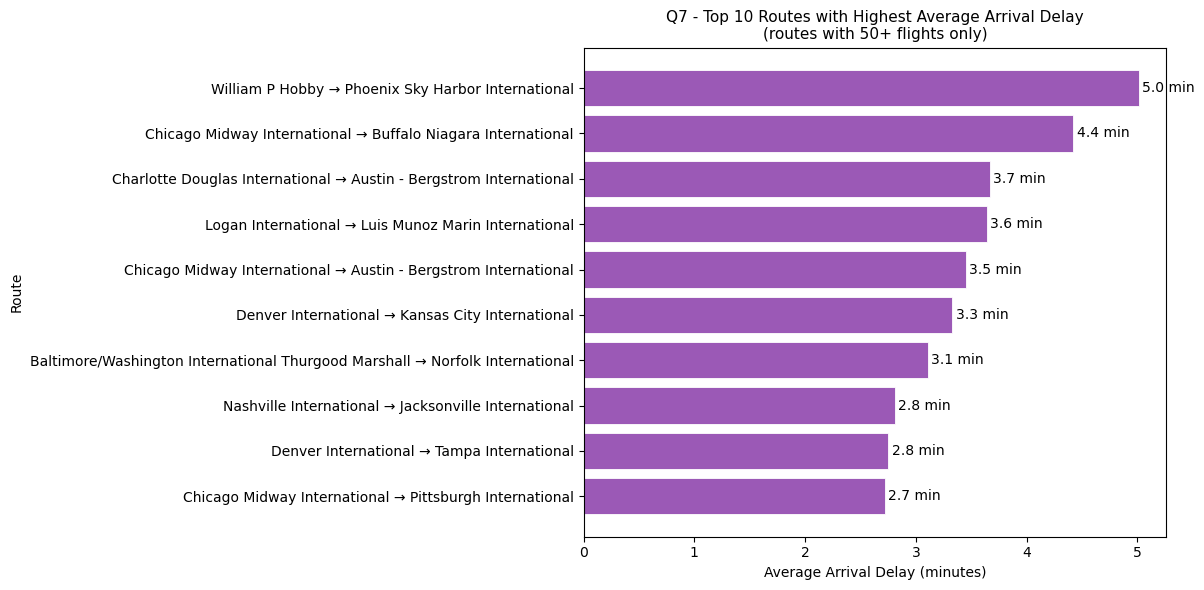


Route with highest avg delay : William P Hobby → Phoenix Sky Harbor International
Average arrival delay        : 5.0 minutes
Total flights on this route  : 70
Note: regional routes with few daily flights have less
recovery time - one cascading delay affects the whole day.


In [93]:
# ============================================================
# QUESTION 7 - Which route has the highest average arrival delay?
# ============================================================
# This question asks for SEVERITY - on average, how many
# minutes late do flights arrive on this route?
# This controls for volume and reveals the truly problematic
# routes regardless of how many flights they operate.
#
# We apply a MINIMUM SAMPLE THRESHOLD of 50 flights.
# A route with only 3 flights where one was 30 minutes late
# would have a high average by coincidence, not pattern.
# 50 flights is the minimum for a reliable average.
#
# CHART TYPE: HORIZONTAL BAR CHART
# Purple colour - visually distinct from Q6's red so the
# reader immediately sees these are two different questions.
 
print("\n" + "=" * 55)
print("Q7 - ROUTES WITH HIGHEST AVERAGE ARRIVAL DELAY")
print("=" * 55)
 
q7_stats = (
    cleaned.assign(Route=cleaned['OriginAirportName'] + ' → ' + cleaned['DestAirportName'])
    .groupby('Route')
    .agg(
        total_flights  = ('ArrDelay', 'count'),
        mean_arr_delay = ('ArrDelay', 'mean'),
    )
    .reset_index()
)
# Minimum sample threshold
q7_stats = q7_stats[q7_stats['total_flights'] >= 50]
 
q7_top10 = (
    q7_stats
    .nlargest(10, 'mean_arr_delay')
    .sort_values('mean_arr_delay', ascending=True)
    .round(2)
)
 
print(q7_top10[['Route','total_flights','mean_arr_delay']]
      .to_string(index=False))
 
# -- Chart ----------------------------------------------------
fig, ax = plt.subplots(figsize=(12, 6))
 
bars = ax.barh(
    q7_top10['Route'],
    q7_top10['mean_arr_delay'],
    color='#9b59b6',   # purple - distinct from Q6 red
    edgecolor='white',
    linewidth=0.6
)
for bar, val in zip(bars, q7_top10['mean_arr_delay']):
    ax.text(
        val + 0.03,
        bar.get_y() + bar.get_height() / 2,
        f'{val:.1f} min',
        va='center', fontsize=10
    )
ax.set_title('Q7 - Top 10 Routes with Highest Average Arrival Delay\n'
             '(routes with 50+ flights only)',
             fontsize=11)
ax.set_xlabel('Average Arrival Delay (minutes)', fontsize=10)
ax.set_ylabel('Route', fontsize=10)
 
plt.tight_layout()
plt.savefig('chart_07_routes_highest_avg_delay.png', dpi=120,
            bbox_inches='tight')
plt.show()
 
top_q7 = q7_top10.iloc[-1]
print(f"\nRoute with highest avg delay : {top_q7['Route']}")
print(f"Average arrival delay        : {top_q7['mean_arr_delay']:.1f} minutes")
print(f"Total flights on this route  : {top_q7['total_flights']:,.0f}")
print(f"Note: regional routes with few daily flights have less")
print(f"recovery time - one cascading delay affects the whole day.")

In [95]:
# ============================================================
# FINAL SUMMARY - all findings in one place
# ============================================================
# Every portfolio project must end with a written summary.
# A GitHub visitor should read this and understand the full
# story without needing to run a single line of code.
 
print("\n" + "=" * 55)
print("ANALYSIS COMPLETE - KEY FINDINGS")
print("=" * 55)
print(f"""
Dataset   : {len(cleaned):,} US domestic flights (Apr-Oct 2013)
            16 airlines | 36 origin states
 
Q1  DELAY DISTRIBUTIONS
    Avg departure delay : {dep_mean:.1f} min  |  Median: {dep_median:.1f} min
    Avg arrival delay   : {arr_mean:.1f} min  |  Median: {arr_median:.1f} min
    Both distributions are right-skewed. Most passengers
    experience on-time or early flights. A tail of severe
    delays pulls the mean above the median.
    The median is the more honest measure of typical experience.
 
Q2  AIRLINES
    Best  : {carrier_stats.iloc[0]['CarrierName']} - avg arrival delay {carrier_stats.iloc[0]['avg_arr_delay']:.1f} min
    Worst : {carrier_stats.iloc[-1]['CarrierName']} - avg arrival delay {carrier_stats.iloc[-1]['avg_arr_delay']:.1f} min
    Gap   : {carrier_stats.iloc[-1]['avg_arr_delay'] - carrier_stats.iloc[0]['avg_arr_delay']:.1f} minutes between best and worst.
 
Q3  DAY OF WEEK
    Worst : {worst_dow} - highest congestion before the weekend
    Best  : {best_dow}  - lowest average delays
    Advice: fly on {best_dow} for the most reliable experience.
 
Q4  AIRPORTS
    Worst : {worst_airport['OriginAirportName']}
    Delay : {worst_airport['mean_dep_delay']:.1f} minutes average departure delay
    Chicago airports dominate. Hub airports cascade delays
    throughout the day as connecting flights pile up.
 
Q5  DEPARTURE vs ARRIVAL DELAY
    Correlation r = {correlation:.2f} - {strength} positive relationship.
    Departing late strongly predicts arriving late.
    Some recovery in the air occurs but rarely enough to
    overcome a significant departure delay.
 
Q6  MOST TOTAL LATE ARRIVALS (FREQUENCY)
    Route : {top_q6['Route']}
    Count : {top_q6['late_arrival_count']:,} late arrivals
    High-volume corridors dominate this list.
 
Q7  HIGHEST AVERAGE ARRIVAL DELAY (SEVERITY)
    Route : {top_q7['Route']}
    Delay : {top_q7['mean_arr_delay']:.1f} minutes average
    Regional routes with fewer daily flights suffer more
    from cascading delays with no recovery buffer.
 
CHARTS SAVED:
    chart_01_delay_distributions.png
    chart_02_carrier_comparison.png
    chart_03_delays_by_day.png
    chart_04_airport_delays.png
    chart_05_dep_vs_arr_delay.png
    chart_06_routes_most_late.png
    chart_07_routes_highest_avg_delay.png
""")


ANALYSIS COMPLETE - KEY FINDINGS

Dataset   : 231,247 US domestic flights (Apr-Oct 2013)
            16 airlines | 36 origin states

Q1  DELAY DISTRIBUTIONS
    Avg departure delay : 0.2 min  |  Median: -2.0 min
    Avg arrival delay   : -4.5 min  |  Median: -5.0 min
    Both distributions are right-skewed. Most passengers
    experience on-time or early flights. A tail of severe
    delays pulls the mean above the median.
    The median is the more honest measure of typical experience.

Q2  AIRLINES
    Best  : UA - avg arrival delay -7.6 min
    Worst : F9 - avg arrival delay -0.1 min
    Gap   : 7.5 minutes between best and worst.

Q3  DAY OF WEEK
    Worst : Thu - highest congestion before the weekend
    Best  : Sat  - lowest average delays
    Advice: fly on Sat for the most reliable experience.

Q4  AIRPORTS
    Worst : Chicago Midway International
    Delay : 4.8 minutes average departure delay
    Chicago airports dominate. Hub airports cascade delays
    throughout the day a